In [ ]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

In [2]:
class DampedOscillatorPhysics(nn.Module):
    """
    State: x = [position, velocity]

    One latent integration step:
        p_{t+1} = p_t + dt * v_t
        v_{t+1} = v_t + dt * (-k * p_t - c * v_t)
    """
    def __init__(self, dt=0.05, spring_k=0.7, damping_c=0.12):
        super().__init__()
        self.dt = dt
        self.spring_k = spring_k
        self.damping_c = damping_c

    def forward(self, x):
        pos = x[..., 0]
        vel = x[..., 1]
        next_pos = pos + self.dt * vel
        next_vel = vel + self.dt * (-self.spring_k * pos - self.damping_c * vel)
        return torch.stack([next_pos, next_vel], dim=-1)

In [3]:
from dataclasses import dataclass


def zero_last_linear(module):
    last = None
    for m in module.modules():
        if isinstance(m, nn.Linear):
            last = m
    if last is not None:
        nn.init.zeros_(last.weight)
        nn.init.zeros_(last.bias)


def mlp(
    sizes,
    activation=nn.SiLU,
    norm=False,
    dropout=0.0,
    zero_last=False,
):
    layers = []
    for i in range(len(sizes) - 1):
        in_dim = sizes[i]
        out_dim = sizes[i + 1]
        layers.append(nn.Linear(in_dim, out_dim))
        if i < len(sizes) - 2:
            if norm:
                layers.append(nn.LayerNorm(out_dim))
            layers.append(activation())
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
    net = nn.Sequential(*layers)
    if zero_last:
        zero_last_linear(net)
    return net


class ParticleLikelihoodHead(nn.Module):
    """
    Pluggable particle likelihood scorer.

    Modes:
      - "mse"
      - "cosine"
      - "bilinear"
      - "mlp"
      - "attention"
      - "hybrid"      (learned weighted combination of all of the above)

    Input:
      obs      : (B, Dy)
      obs_feat : (B, E)
      particles: (B, N, Dx)
      pred_obs : (B, N, Dy)

    Output:
      scores   : (B, N), unnormalized log-scores
    """

    def __init__(
        self,
        dim_x,
        dim_y,
        obs_embed_dim,
        hidden_size,
        mode="hybrid",
        match_dim=64,
        num_heads=4,
    ):
        super().__init__()
        assert match_dim % num_heads == 0

        self.dim_x = dim_x
        self.dim_y = dim_y
        self.obs_embed_dim = obs_embed_dim
        self.hidden_size = hidden_size
        self.mode = mode
        self.match_dim = match_dim
        self.num_heads = num_heads
        self.head_dim = match_dim // num_heads

        self.particle_encoder = mlp(
            [dim_x, hidden_size, hidden_size],
            norm=False,
            dropout=0.0,
        )

        self.pred_obs_encoder = mlp(
            [dim_y, hidden_size, match_dim],
            norm=False,
            dropout=0.0,
        )

        self.obs_match_proj = nn.Linear(obs_embed_dim, match_dim)
        self.particle_match_proj = nn.Linear(hidden_size, match_dim)
        self.bilinear_proj = nn.Linear(match_dim, match_dim, bias=False)

        self.mlp_score = mlp(
            [hidden_size + obs_embed_dim + match_dim + 2 * dim_y, hidden_size, hidden_size, 1],
            norm=False,
            dropout=0.0,
        )

        self.attn_local = mlp(
            [match_dim + 2 * dim_y, hidden_size, 1],
            norm=False,
            dropout=0.0,
        )

        self.log_precision = nn.Parameter(torch.zeros(dim_y))
        self.mse_bias = nn.Parameter(torch.zeros(1))
        self.cos_scale = nn.Parameter(torch.tensor(1.0))
        self.attn_scale = nn.Parameter(torch.tensor(1.0))
        self.hybrid_logits = nn.Parameter(torch.zeros(5))

    def _standardize(self, score):
        mean = score.mean(dim=1, keepdim=True)
        std = score.std(dim=1, keepdim=True).clamp_min(1e-4)
        return (score - mean) / std

    def forward(self, obs, obs_feat, particles, pred_obs):
        """
        Returns centered per-particle log-scores.
        """
        b, n, _ = particles.shape

        obs_expanded = obs[:, None, :].expand(-1, n, -1)
        obs_feat_expanded = obs_feat[:, None, :].expand(-1, n, -1)

        part_feat = self.particle_encoder(particles)              # (B, N, H)
        pred_feat = self.pred_obs_encoder(pred_obs)               # (B, N, M)
        residual = obs_expanded - pred_obs                        # (B, N, Dy)

        # 1) MSE-like score with learned precision
        precision = F.softplus(self.log_precision)[None, None, :] + 1e-4
        score_mse = -(precision * residual.square()).sum(dim=-1) + self.mse_bias

        # 2) Cosine score between encoded observation and decoded particle observation
        obs_match = F.normalize(self.obs_match_proj(obs_feat), dim=-1)           # (B, M)
        pred_match = F.normalize(pred_feat, dim=-1)                              # (B, N, M)
        score_cos = self.cos_scale * (obs_match[:, None, :] * pred_match).sum(dim=-1)

        # 3) Bilinear score between observation embedding and particle embedding
        particle_match = self.particle_match_proj(part_feat)                     # (B, N, M)
        bilinear_q = self.bilinear_proj(obs_match)[:, None, :]                  # (B, 1, M)
        score_bilinear = (bilinear_q * particle_match).sum(dim=-1) / math.sqrt(self.match_dim)

        # 4) MLP critic with explicit residual features
        mlp_inp = torch.cat(
            [part_feat, obs_feat_expanded, pred_feat, residual, residual.square()],
            dim=-1,
        )
        score_mlp = self.mlp_score(mlp_inp).squeeze(-1)

        # 5) Attention-style score
        q = self.obs_match_proj(obs_feat).view(b, self.num_heads, self.head_dim)          # (B, H, Dh)
        k = particle_match.view(b, n, self.num_heads, self.head_dim)                       # (B, N, H, Dh)
        attn_logits = (q[:, None, :, :] * k).sum(dim=-1).mean(dim=-1) / math.sqrt(self.head_dim)
        local = self.attn_local(torch.cat([pred_feat, residual, residual.square()], dim=-1)).squeeze(-1)
        score_attention = self.attn_scale * attn_logits + 0.25 * local

        if self.mode == "mse":
            score = score_mse
        elif self.mode == "cosine":
            score = score_cos
        elif self.mode == "bilinear":
            score = score_bilinear
        elif self.mode == "mlp":
            score = score_mlp
        elif self.mode == "attention":
            score = score_attention
        elif self.mode == "hybrid":
            comps = torch.stack(
                [
                    self._standardize(score_mse),
                    self._standardize(score_cos),
                    self._standardize(score_bilinear),
                    self._standardize(score_mlp),
                    self._standardize(score_attention),
                ],
                dim=-1,
            )  # (B, N, 5)
            weights = torch.softmax(self.hybrid_logits, dim=0)
            score = (comps * weights[None, None, :]).sum(dim=-1)
        else:
            raise ValueError(f"Unknown likelihood mode: {self.mode}")

        # center only; do not squash through sigmoid
        score = score - score.mean(dim=1, keepdim=True)
        return score


@dataclass
class DPFOutput:
    prior_state_estimates: torch.Tensor
    posterior_state_estimates: torch.Tensor
    prior_obs_estimates: torch.Tensor
    posterior_obs_estimates: torch.Tensor
    log_evidence: torch.Tensor
    ess: torch.Tensor
    prior_particle_history: torch.Tensor
    posterior_particle_history: torch.Tensor
    prior_log_weight_history: torch.Tensor
    posterior_log_weight_history: torch.Tensor

In [4]:
class DeepParticleFilter(nn.Module):
    """
    Observation-only differentiable particle filter.

    Training uses observations only.
    True hidden states are never used inside the training losses.

    Loop:
      - initialize particles from y_0 and noise
      - for each t >= 1:
            predict n_pred times using previous observation y_{t-1}
            update weights using current observation y_t
    """

    def __init__(
        self,
        dim_x,
        dim_y,
        n_particles,
        n_pred,
        dt,
        hidden_size=96,
        obs_embed_dim=32,
        init_noise_dim=8,
        transition_noise_dim=8,
        likelihood_mode="hybrid",
        likelihood_match_dim=64,
        likelihood_num_heads=4,
        ess_threshold=0.5,
        contrastive_temperature=0.10,
    ):
        super().__init__()

        self.dim_x = dim_x
        self.dim_y = dim_y
        self.n_particles = n_particles
        self.n_pred = n_pred
        self.dt = dt
        self.obs_embed_dim = obs_embed_dim
        self.init_noise_dim = init_noise_dim
        self.transition_noise_dim = transition_noise_dim
        self.ess_threshold = ess_threshold
        self.contrastive_temperature = contrastive_temperature

        # Shared observation encoder
        self.obs_encoder = mlp(
            [dim_y, hidden_size, hidden_size, obs_embed_dim],
            norm=False,
            dropout=0.0,
        )

        # Initial particle sampler x0 = g(y0, z0)
        self.init_sampler = mlp(
            [obs_embed_dim + init_noise_dim, hidden_size, hidden_size, hidden_size, dim_x],
            norm=False,
            dropout=0.0,
        )

        # Transition residuals
        self.transition_det = mlp(
            [dim_x + obs_embed_dim + 1, hidden_size, hidden_size, hidden_size, dim_x],
            norm=False,
            dropout=0.0,
            zero_last=True,
        )
        self.transition_stoch = mlp(
            [dim_x + obs_embed_dim + transition_noise_dim + 1, hidden_size, hidden_size, hidden_size, dim_x],
            norm=False,
            dropout=0.0,
            zero_last=True,
        )

        # Observation decoder for reconstruction / plotting
        # Soft anchor: first latent coordinates should carry observable quantity
        self.obs_residual_net = mlp(
            [dim_x, hidden_size, hidden_size, hidden_size, dim_y],
            norm=False,
            dropout=0.0,
            zero_last=True,
        )

        # Likelihood scorer
        self.likelihood_head = ParticleLikelihoodHead(
            dim_x=dim_x,
            dim_y=dim_y,
            obs_embed_dim=obs_embed_dim,
            hidden_size=hidden_size,
            mode=likelihood_mode,
            match_dim=likelihood_match_dim,
            num_heads=likelihood_num_heads,
        )

        self._particles = None
        self._log_weights = None
        self._last_obs = None

    # ------------------------------------------------------------
    # Basic utilities
    # ------------------------------------------------------------
    @property
    def particles(self):
        return self._particles

    @property
    def log_weights(self):
        return self._log_weights

    @property
    def weights(self):
        return self._log_weights.exp()

    def encode_obs(self, obs):
        return self.obs_encoder(obs)

    def _uniform_log_weights(self, batch_size, device, dtype):
        return torch.full(
            (batch_size, self.n_particles),
            -math.log(self.n_particles),
            device=device,
            dtype=dtype,
        )

    def _expand_obs_features(self, obs, n_particles):
        feat = self.encode_obs(obs)[:, None, :]
        return feat.expand(-1, n_particles, -1)

    def _dt_feature(self, batch_size, n_particles, device, dtype):
        return torch.full(
            (batch_size, n_particles, 1),
            self.dt,
            device=device,
            dtype=dtype,
        )

    # ------------------------------------------------------------
    # Observation decoder / estimates
    # ------------------------------------------------------------
    def particle_observation_predictions(self, particles=None):
        if particles is None:
            particles = self._particles
        base = particles[..., :self.dim_y]
        residual = 0.10 * self.obs_residual_net(particles)
        return base + residual

    def estimate_state_from(self, particles, log_weights):
        weights = log_weights.exp().unsqueeze(-1)
        return torch.sum(weights * particles, dim=1)

    def estimate_observation_from(self, particles, log_weights):
        weights = log_weights.exp().unsqueeze(-1)
        particle_obs = self.particle_observation_predictions(particles)
        return torch.sum(weights * particle_obs, dim=1)

    def effective_sample_size_from(self, log_weights):
        weights = log_weights.exp()
        return 1.0 / torch.sum(weights.square(), dim=1).clamp_min(1e-12)

    # ------------------------------------------------------------
    # Initialization
    # ------------------------------------------------------------
    def sample_initial_particles(self, init_obs):
        batch_size = init_obs.shape[0]
        device = init_obs.device
        dtype = init_obs.dtype

        obs_feat = self._expand_obs_features(init_obs, self.n_particles)
        z0 = torch.randn(
            batch_size,
            self.n_particles,
            self.init_noise_dim,
            device=device,
            dtype=dtype,
        )
        init_inp = torch.cat([obs_feat, z0], dim=-1)
        return self.init_sampler(init_inp)

    def reset(self, batch_size, device=None, init_obs=None):
        if device is None:
            device = next(self.parameters()).device

        if init_obs is None:
            self._particles = torch.randn(batch_size, self.n_particles, self.dim_x, device=device)
            self._last_obs = None
        else:
            self._particles = self.sample_initial_particles(init_obs)
            self._last_obs = init_obs

        self._log_weights = self._uniform_log_weights(
            batch_size=batch_size,
            device=self._particles.device,
            dtype=self._particles.dtype,
        )
        return self.estimate_state_from(self._particles, self._log_weights)

    # ------------------------------------------------------------
    # Transition
    # ------------------------------------------------------------
    def transition_step_from_particles(self, particles, prev_obs):
        """
        x' = x + dt * f_det(x, y_prev) + dt * f_stoch(x, y_prev, z)
        """
        batch_size, n_particles, _ = particles.shape
        device = particles.device
        dtype = particles.dtype

        obs_feat = self._expand_obs_features(prev_obs, n_particles)
        dt_feat = self._dt_feature(batch_size, n_particles, device, dtype)

        det_inp = torch.cat([particles, obs_feat, dt_feat], dim=-1)
        det_delta = self.transition_det(det_inp)

        z = torch.randn(
            batch_size,
            n_particles,
            self.transition_noise_dim,
            device=device,
            dtype=dtype,
        )
        stoch_inp = torch.cat([particles, obs_feat, z, dt_feat], dim=-1)
        stoch_delta = self.transition_stoch(stoch_inp)

        # Center the stochastic part to prevent global drift of the whole cloud.
        stoch_delta = stoch_delta - stoch_delta.mean(dim=1, keepdim=True)

        return particles + self.dt * (det_delta + stoch_delta)

    def predict_particles(self, particles, prev_obs, n_steps=None):
        if n_steps is None:
            n_steps = self.n_pred
        x = particles
        for _ in range(n_steps):
            x = self.transition_step_from_particles(x, prev_obs)
        return x

    def predict_once(self):
        if self._last_obs is None:
            raise RuntimeError("predict_once() requires previous observation. Call reset(..., init_obs=...) first.")
        self._particles = self.transition_step_from_particles(self._particles, self._last_obs)
        return self._particles

    def predict_n_steps(self, n_steps=None):
        if n_steps is None:
            n_steps = self.n_pred
        for _ in range(n_steps):
            self.predict_once()
        return self._particles

    # ------------------------------------------------------------
    # Likelihood / weight update
    # ------------------------------------------------------------
    def particle_log_scores(self, obs, particles):
        obs_feat = self.encode_obs(obs)
        pred_obs = self.particle_observation_predictions(particles)
        return self.likelihood_head(obs, obs_feat, particles, pred_obs)

    def cloud_score_matrix(self, particles, obs_candidates):
        """
        Memory-friendly version: loops over candidate observations instead of
        materializing a full (B,B,N,...) tensor.
        Returns score[b, k] = compatibility(cloud_b, obs_k)
        """
        b = particles.shape[0]
        scores = []
        for k in range(b):
            obs_k = obs_candidates[k : k + 1].expand(b, -1)
            part_scores = self.particle_log_scores(obs_k, particles)  # (B, N)
            cloud_scores = torch.logsumexp(part_scores, dim=1) - math.log(self.n_particles)
            scores.append(cloud_scores)
        return torch.stack(scores, dim=1)  # (B, B)

    def score_spread_loss(self, scores, min_std=0.25):
        std = scores.std(dim=1).mean()
        return F.relu(min_std - std)

    def systematic_resample(self, weights):
        b, n = weights.shape
        cdf = torch.cumsum(weights, dim=1)
        cdf[:, -1] = 1.0

        u0 = torch.rand(b, 1, device=weights.device) / n
        positions = u0 + torch.arange(n, device=weights.device).view(1, n) / n

        idx = (positions.unsqueeze(-1) > cdf.unsqueeze(1)).sum(dim=-1)
        return idx.clamp(max=n - 1)

    def maybe_resample(self, ess=None):
        if ess is None:
            ess = self.effective_sample_size_from(self._log_weights)

        need = ess < (self.ess_threshold * self.n_particles)
        if not need.any():
            return

        weights = self.weights[need]
        idx = self.systematic_resample(weights)

        selected_particles = self._particles[need].gather(
            dim=1,
            index=idx.unsqueeze(-1).expand(-1, -1, self.dim_x),
        )

        self._particles = self._particles.clone()
        self._particles[need] = selected_particles

        self._log_weights = self._log_weights.clone()
        self._log_weights[need] = -math.log(self.n_particles)

    def update(self, obs, resample=True):
        """
        Returns posterior snapshots BEFORE optional resampling.
        """
        log_like = self.particle_log_scores(obs, self._particles)
        new_log_weights = self._log_weights + log_like
        log_norm = torch.logsumexp(new_log_weights, dim=1, keepdim=True)
        new_log_weights = new_log_weights - log_norm

        self._log_weights = new_log_weights

        posterior_particles = self._particles.clone()
        posterior_log_weights = self._log_weights.clone()

        posterior_state = self.estimate_state_from(posterior_particles, posterior_log_weights)
        posterior_obs = self.estimate_observation_from(posterior_particles, posterior_log_weights)
        ess = self.effective_sample_size_from(posterior_log_weights)

        if resample:
            self.maybe_resample(ess)

        self._last_obs = obs

        return (
            posterior_state,
            posterior_obs,
            log_norm.squeeze(1),
            ess,
            posterior_particles,
            posterior_log_weights,
        )

    def step(self, obs, n_pred=None, resample=True):
        self.predict_n_steps(n_pred)

        prior_particles = self._particles.clone()
        prior_log_weights = self._log_weights.clone()

        prior_state = self.estimate_state_from(prior_particles, prior_log_weights)
        prior_obs = self.estimate_observation_from(prior_particles, prior_log_weights)

        (
            posterior_state,
            posterior_obs,
            log_evidence,
            ess,
            posterior_particles,
            posterior_log_weights,
        ) = self.update(obs, resample=resample)

        return (
            prior_state,
            posterior_state,
            prior_obs,
            posterior_obs,
            log_evidence,
            ess,
            prior_particles,
            posterior_particles,
            prior_log_weights,
            posterior_log_weights,
        )

    def forward(self, obs_seq, resample=False):
        batch_size, seq_len, _ = obs_seq.shape
        device = obs_seq.device

        self.reset(batch_size=batch_size, device=device, init_obs=obs_seq[:, 0])

        init_particles = self._particles.clone()
        init_log_weights = self._log_weights.clone()

        prior_state_estimates = [self.estimate_state_from(init_particles, init_log_weights)]
        posterior_state_estimates = [self.estimate_state_from(init_particles, init_log_weights)]
        prior_obs_estimates = [self.estimate_observation_from(init_particles, init_log_weights)]
        posterior_obs_estimates = [self.estimate_observation_from(init_particles, init_log_weights)]
        log_evidence = [torch.zeros(batch_size, device=device, dtype=obs_seq.dtype)]
        ess_values = [self.effective_sample_size_from(init_log_weights)]
        prior_particle_history = [init_particles]
        posterior_particle_history = [init_particles]
        prior_log_weight_history = [init_log_weights]
        posterior_log_weight_history = [init_log_weights]

        for t in range(1, seq_len):
            (
                prior_state,
                posterior_state,
                prior_obs,
                posterior_obs,
                log_ev,
                ess,
                prior_particles,
                posterior_particles,
                prior_log_weights,
                posterior_log_weights,
            ) = self.step(
                obs=obs_seq[:, t],
                n_pred=self.n_pred,
                resample=resample,
            )

            prior_state_estimates.append(prior_state)
            posterior_state_estimates.append(posterior_state)
            prior_obs_estimates.append(prior_obs)
            posterior_obs_estimates.append(posterior_obs)
            log_evidence.append(log_ev)
            ess_values.append(ess)
            prior_particle_history.append(prior_particles)
            posterior_particle_history.append(posterior_particles)
            prior_log_weight_history.append(prior_log_weights)
            posterior_log_weight_history.append(posterior_log_weights)

        return DPFOutput(
            prior_state_estimates=torch.stack(prior_state_estimates, dim=1),
            posterior_state_estimates=torch.stack(posterior_state_estimates, dim=1),
            prior_obs_estimates=torch.stack(prior_obs_estimates, dim=1),
            posterior_obs_estimates=torch.stack(posterior_obs_estimates, dim=1),
            log_evidence=torch.stack(log_evidence, dim=1),
            ess=torch.stack(ess_values, dim=1),
            prior_particle_history=torch.stack(prior_particle_history, dim=1),
            posterior_particle_history=torch.stack(posterior_particle_history, dim=1),
            prior_log_weight_history=torch.stack(prior_log_weight_history, dim=1),
            posterior_log_weight_history=torch.stack(posterior_log_weight_history, dim=1),
        )

    # ------------------------------------------------------------
    # Self-supervised losses
    # ------------------------------------------------------------
    def particle_diversity_loss(self, particles, min_std=0.03, max_std=3.0):
        std = particles.std(dim=1)
        low = F.relu(min_std - std).mean()
        high = F.relu(std - max_std).mean()
        energy = 1e-4 * particles.square().mean()
        return low + 0.1 * high + energy

    def _sample_time_indices(self, seq_len, n_samples, device):
        if seq_len <= 1:
            return torch.zeros(1, dtype=torch.long, device=device)
        n_samples = min(n_samples, seq_len - 1)
        return torch.randperm(seq_len - 1, device=device)[:n_samples] + 1

    def initializer_pretrain_loss(self, obs_seq, n_obs_samples=64):
        flat_obs = obs_seq.reshape(-1, self.dim_y)

        if flat_obs.shape[0] > n_obs_samples:
            idx = torch.randint(0, flat_obs.shape[0], (n_obs_samples,), device=flat_obs.device)
            obs = flat_obs[idx]
        else:
            obs = flat_obs

        particles = self.sample_initial_particles(obs)
        log_weights = self._uniform_log_weights(
            batch_size=obs.shape[0],
            device=obs.device,
            dtype=particles.dtype,
        )
        obs_hat = self.estimate_observation_from(particles, log_weights)

        recon = F.smooth_l1_loss(obs_hat, obs)
        diversity = self.particle_diversity_loss(particles)
        total = recon + 0.05 * diversity

        return {
            "loss": total,
            "recon": recon,
            "diversity": diversity,
        }

    def bootstrap_predict_from_observation(self, prev_obs, n_steps=None):
        particles = self.sample_initial_particles(prev_obs)
        particles = self.predict_particles(particles, prev_obs, n_steps=n_steps)
        log_weights = self._uniform_log_weights(
            batch_size=prev_obs.shape[0],
            device=prev_obs.device,
            dtype=particles.dtype,
        )
        return particles, log_weights

    def transition_pretrain_loss(self, obs_seq, n_time_samples=2):
        _, seq_len, _ = obs_seq.shape
        t_idx = self._sample_time_indices(seq_len, n_time_samples, obs_seq.device)

        pred_losses = []
        div_losses = []

        for t in t_idx:
            pred_particles, pred_log_weights = self.bootstrap_predict_from_observation(
                prev_obs=obs_seq[:, t - 1],
                n_steps=self.n_pred,
            )
            pred_obs = self.estimate_observation_from(pred_particles, pred_log_weights)

            pred_losses.append(F.smooth_l1_loss(pred_obs, obs_seq[:, t]))
            div_losses.append(self.particle_diversity_loss(pred_particles))

        pred_recon = torch.stack(pred_losses).mean()
        diversity = torch.stack(div_losses).mean()
        total = pred_recon + 0.05 * diversity

        return {
            "loss": total,
            "pred_recon": pred_recon,
            "diversity": diversity,
        }

    def likelihood_pretrain_loss(self, obs_seq, n_time_samples=2):
        batch_size, seq_len, _ = obs_seq.shape
        t_idx = self._sample_time_indices(seq_len, n_time_samples, obs_seq.device)

        nce_losses = []
        spread_losses = []

        for t in t_idx:
            pred_particles, _ = self.bootstrap_predict_from_observation(
                prev_obs=obs_seq[:, t - 1],
                n_steps=self.n_pred,
            )

            score_matrix = self.cloud_score_matrix(pred_particles, obs_seq[:, t])
            targets = torch.arange(batch_size, device=obs_seq.device)
            nce_losses.append(
                F.cross_entropy(score_matrix / self.contrastive_temperature, targets)
            )

            pos_scores = self.particle_log_scores(obs_seq[:, t], pred_particles)
            spread_losses.append(self.score_spread_loss(pos_scores))

        nce = torch.stack(nce_losses).mean()
        spread = torch.stack(spread_losses).mean()
        total = nce + 0.10 * spread

        return {
            "loss": total,
            "nce": nce,
            "spread": spread,
        }

    def end_to_end_selfsup_loss(self, obs_seq, resample=False, n_nce_steps=2):
        out = self(obs_seq, resample=resample)

        post_recon = F.smooth_l1_loss(out.posterior_obs_estimates, obs_seq)

        if obs_seq.shape[1] > 1:
            prior_pred = F.smooth_l1_loss(
                out.prior_obs_estimates[:, 1:],
                obs_seq[:, 1:],
            )

            prior_err = (out.prior_obs_estimates[:, 1:] - obs_seq[:, 1:]).abs().mean(dim=-1)
            post_err = (out.posterior_obs_estimates[:, 1:] - obs_seq[:, 1:]).abs().mean(dim=-1)
            innovation = F.relu(post_err - prior_err + 1e-3).mean()

            t_idx = self._sample_time_indices(obs_seq.shape[1], n_nce_steps, obs_seq.device)
            nce_losses = []
            spread_losses = []
            for t in t_idx:
                score_matrix = self.cloud_score_matrix(
                    out.prior_particle_history[:, t],
                    obs_seq[:, t],
                )
                targets = torch.arange(obs_seq.shape[0], device=obs_seq.device)
                nce_losses.append(
                    F.cross_entropy(score_matrix / self.contrastive_temperature, targets)
                )

                pos_scores = self.particle_log_scores(
                    obs_seq[:, t],
                    out.prior_particle_history[:, t],
                )
                spread_losses.append(self.score_spread_loss(pos_scores))

            nce = torch.stack(nce_losses).mean()
            spread = torch.stack(spread_losses).mean()

            ess_reg = ((out.ess[:, 1:] / self.n_particles) - 0.40).square().mean()

            diversity = self.particle_diversity_loss(
                out.prior_particle_history[:, 1:].reshape(-1, self.n_particles, self.dim_x)
            )
        else:
            prior_pred = torch.zeros((), device=obs_seq.device, dtype=obs_seq.dtype)
            innovation = torch.zeros((), device=obs_seq.device, dtype=obs_seq.dtype)
            nce = torch.zeros((), device=obs_seq.device, dtype=obs_seq.dtype)
            spread = torch.zeros((), device=obs_seq.device, dtype=obs_seq.dtype)
            ess_reg = torch.zeros((), device=obs_seq.device, dtype=obs_seq.dtype)
            diversity = torch.zeros((), device=obs_seq.device, dtype=obs_seq.dtype)

        total = (
            1.00 * post_recon
            + 0.50 * prior_pred
            + 0.25 * nce
            + 0.10 * innovation
            + 0.05 * spread
            + 0.05 * diversity
            + 0.02 * ess_reg
        )

        return {
            "loss": total,
            "post_recon": post_recon,
            "prior_pred": prior_pred,
            "nce": nce,
            "spread": spread,
            "innovation": innovation,
            "ess_reg": ess_reg,
            "diversity": diversity,
        }, out

In [5]:
@torch.no_grad()
def simulate_damped_oscillator_dataset(
    n_sequences,
    seq_len_obs,
    n_pred,
    dt,
    spring_k=0.7,
    damping_c=0.12,
    process_std=(0.02, 0.03),
    obs_std=0.08,
    device="cpu",
):
    """
    Generates batched synthetic data.

    Important convention:
      - observation at index 0 is at the initial state
      - then between observation t and t+1 there are exactly n_pred latent steps
    """
    x = torch.zeros(n_sequences, 2, device=device)
    x[:, 0] = torch.empty(n_sequences, device=device).uniform_(-1.5, 1.5)
    x[:, 1] = torch.empty(n_sequences, device=device).uniform_(-0.5, 0.5)

    hidden_at_obs = [x.clone()]
    observations = [x[:, 0:1] + obs_std * torch.randn(n_sequences, 1, device=device)]

    process_std_tensor = torch.tensor(process_std, device=device)

    for _ in range(seq_len_obs - 1):
        for _ in range(n_pred):
            pos = x[:, 0]
            vel = x[:, 1]
            next_pos = pos + dt * vel
            next_vel = vel + dt * (-spring_k * pos - damping_c * vel)
            x = torch.stack([next_pos, next_vel], dim=-1)
            x = x + torch.randn_like(x) * process_std_tensor

        hidden_at_obs.append(x.clone())
        observations.append(x[:, 0:1] + obs_std * torch.randn(n_sequences, 1, device=device))

    hidden_at_obs = torch.stack(hidden_at_obs, dim=1)  # (N, T, 2)
    observations = torch.stack(observations, dim=1)    # (N, T, 1)
    return hidden_at_obs, observations


In [6]:
import tqdm

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(7)

In [9]:
# -----------------------------
# Synthetic data
# -----------------------------
train_states, train_obs = simulate_damped_oscillator_dataset(
    n_sequences=256,
    seq_len_obs=seq_len_obs,
    n_pred=n_pred,
    dt=dt,
    device=device,
)
test_states, test_obs = simulate_damped_oscillator_dataset(
    n_sequences=32,
    seq_len_obs=seq_len_obs,
    n_pred=n_pred,
    dt=dt,
    device=device,
)

In [10]:
train_loader = DataLoader(
    TensorDataset(train_obs),
    batch_size=16,
    shuffle=True,
    drop_last=True,
)

In [8]:
# -----------------------------
# Problem dimensions
# -----------------------------
dim_x = 2
dim_y = 1
n_particles = 256
n_pred = 5
dt = 0.05
seq_len_obs = 100

In [31]:
likelihood_mode = "hybrid"
# options:
# "mse", "cosine", "bilinear", "mlp", "attention", "hybrid"

dpf = DeepParticleFilter(
    dim_x=dim_x,
    dim_y=dim_y,
    n_particles=n_particles,
    n_pred=n_pred,
    dt=dt,
    hidden_size=96,
    obs_embed_dim=32,
    init_noise_dim=8,
    transition_noise_dim=8,
    likelihood_mode=likelihood_mode,
    likelihood_match_dim=64,
    likelihood_num_heads=4,
    ess_threshold=0.5,
    contrastive_temperature=0.10,
).to(device)

In [32]:
def set_requires_grad(module, flag: bool):
    for p in module.parameters():
        p.requires_grad = flag


def set_stage_trainable(dpf, stage_name: str):
    modules = {
        "obs_encoder": dpf.obs_encoder,
        "init_sampler": dpf.init_sampler,
        "transition_det": dpf.transition_det,
        "transition_stoch": dpf.transition_stoch,
        "obs_residual_net": dpf.obs_residual_net,
        "likelihood_head": dpf.likelihood_head,
    }

    for m in modules.values():
        set_requires_grad(m, False)

    if stage_name == "init_pretrain":
        for name in ["obs_encoder", "init_sampler", "obs_residual_net"]:
            set_requires_grad(modules[name], True)

    elif stage_name == "transition_pretrain":
        for name in ["obs_encoder", "init_sampler", "transition_det", "transition_stoch", "obs_residual_net"]:
            set_requires_grad(modules[name], True)

    elif stage_name == "likelihood_pretrain":
        for name in ["obs_encoder", "likelihood_head"]:
            set_requires_grad(modules[name], True)

    elif stage_name in {"e2e_warmup", "e2e_finetune"}:
        for m in modules.values():
            set_requires_grad(m, True)

    else:
        raise ValueError(f"Unknown stage: {stage_name}")


def make_random_window_obs(obs_batch, window_len):
    total_len = obs_batch.shape[1]
    if window_len >= total_len:
        return obs_batch

    start = torch.randint(
        low=0,
        high=total_len - window_len + 1,
        size=(1,),
        device=obs_batch.device,
    ).item()
    end = start + window_len
    return obs_batch[:, start:end]


stage_specs = [
    {"name": "init_pretrain",       "epochs": 6,  "lr": 2e-3},
    {"name": "transition_pretrain", "epochs": 20, "lr": 2e-3},
    {"name": "likelihood_pretrain", "epochs": 20,  "lr": 8e-4},
    {"name": "e2e_warmup",          "epochs": 20, "lr": 8e-4},
    {"name": "e2e_finetune",        "epochs": 10,  "lr": 5e-4},
]

for stage in stage_specs:
    stage_name = stage["name"]
    set_stage_trainable(dpf, stage_name)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, dpf.parameters()),
        lr=stage["lr"],
        weight_decay=1e-5,
    )

    for epoch in range(stage["epochs"]):
        dpf.train()

        loss_sum = 0.0
        recon_sum = 0.0
        pred_sum = 0.0
        nce_sum = 0.0
        spread_sum = 0.0
        innov_sum = 0.0
        ess_sum = 0.0
        div_sum = 0.0
        n_batches = 0

        for (obs_batch_cpu,) in train_loader:
            obs_batch = obs_batch_cpu.to(device)

            if stage_name in {"e2e_warmup", "e2e_finetune"}:
                obs_batch = make_random_window_obs(obs_batch, window_len=20)

            optimizer.zero_grad()

            if stage_name == "init_pretrain":
                losses = dpf.initializer_pretrain_loss(
                    obs_seq=obs_batch,
                    n_obs_samples=64,
                )

            elif stage_name == "transition_pretrain":
                losses = dpf.transition_pretrain_loss(
                    obs_seq=obs_batch,
                    n_time_samples=2,
                )

            elif stage_name == "likelihood_pretrain":
                losses = dpf.likelihood_pretrain_loss(
                    obs_seq=obs_batch,
                    n_time_samples=2,
                )

            elif stage_name == "e2e_warmup":
                losses, out = dpf.end_to_end_selfsup_loss(
                    obs_seq=obs_batch,
                    resample=False,
                    n_nce_steps=2,
                )
                ess_sum += out.ess.mean().item()

            elif stage_name == "e2e_finetune":
                losses, out = dpf.end_to_end_selfsup_loss(
                    obs_seq=obs_batch,
                    resample=True,
                    n_nce_steps=2,
                )
                ess_sum += out.ess.mean().item()

            else:
                raise ValueError(stage_name)

            loss = losses["loss"]
            loss.backward()
            torch.nn.utils.clip_grad_norm_(dpf.parameters(), max_norm=5.0)
            optimizer.step()

            loss_sum += loss.item()
            if "recon" in losses:
                recon_sum += losses["recon"].item()
            if "pred_recon" in losses:
                pred_sum += losses["pred_recon"].item()
            if "post_recon" in losses:
                recon_sum += losses["post_recon"].item()
            if "prior_pred" in losses:
                pred_sum += losses["prior_pred"].item()
            if "nce" in losses:
                nce_sum += losses["nce"].item()
            if "spread" in losses:
                spread_sum += losses["spread"].item()
            if "innovation" in losses:
                innov_sum += losses["innovation"].item()
            if "diversity" in losses:
                div_sum += losses["diversity"].item()

            n_batches += 1

        msg = f"[{stage_name}] epoch={epoch:02d} loss={loss_sum / n_batches:.4f}"

        if stage_name == "init_pretrain":
            msg += (
                f" recon={recon_sum / n_batches:.4f}"
                f" div={div_sum / n_batches:.4f}"
            )

        elif stage_name == "transition_pretrain":
            msg += (
                f" pred={pred_sum / n_batches:.4f}"
                f" div={div_sum / n_batches:.4f}"
            )

        elif stage_name == "likelihood_pretrain":
            msg += (
                f" nce={nce_sum / n_batches:.4f}"
                f" spread={spread_sum / n_batches:.4f}"
            )

        else:
            msg += (
                f" post={recon_sum / n_batches:.4f}"
                f" prior={pred_sum / n_batches:.4f}"
                f" nce={nce_sum / n_batches:.4f}"
                f" spread={spread_sum / n_batches:.4f}"
                f" innov={innov_sum / n_batches:.4f}"
                f" div={div_sum / n_batches:.4f}"
                f" ess={ess_sum / n_batches:.2f}"
            )

        print(msg)

[init_pretrain] epoch=00 loss=0.0857 recon=0.0854 div=0.0050
[init_pretrain] epoch=01 loss=0.0101 recon=0.0101 div=0.0000
[init_pretrain] epoch=02 loss=0.0022 recon=0.0022 div=0.0000
[init_pretrain] epoch=03 loss=0.0007 recon=0.0007 div=0.0000
[init_pretrain] epoch=04 loss=0.0002 recon=0.0002 div=0.0000
[init_pretrain] epoch=05 loss=0.0001 recon=0.0001 div=0.0000
[transition_pretrain] epoch=00 loss=0.0214 pred=0.0214 div=0.0000
[transition_pretrain] epoch=01 loss=0.0245 pred=0.0245 div=0.0000
[transition_pretrain] epoch=02 loss=0.0184 pred=0.0184 div=0.0000
[transition_pretrain] epoch=03 loss=0.0174 pred=0.0174 div=0.0000
[transition_pretrain] epoch=04 loss=0.0145 pred=0.0145 div=0.0000
[transition_pretrain] epoch=05 loss=0.0155 pred=0.0155 div=0.0000
[transition_pretrain] epoch=06 loss=0.0163 pred=0.0163 div=0.0000
[transition_pretrain] epoch=07 loss=0.0169 pred=0.0169 div=0.0000
[transition_pretrain] epoch=08 loss=0.0139 pred=0.0139 div=0.0000
[transition_pretrain] epoch=09 loss=0.01

In [33]:
import matplotlib.pyplot as plt
import torch


def plot_filter_results(
    true_states,
    state_estimates,
    true_observations,
    observation_estimates,
    ess=None,
    sequence_index=0,
):
    """
    true_states:           (batch, T, dim_x)
    state_estimates:       (batch, T, dim_x)
    true_observations:     (batch, T, dim_y)
    observation_estimates: (batch, T, dim_y)
    ess:                   (batch, T) or None
    """

    true_states = true_states.detach().cpu()
    state_estimates = state_estimates.detach().cpu()
    true_observations = true_observations.detach().cpu()
    observation_estimates = observation_estimates.detach().cpu()
    ess_cpu = ess.detach().cpu() if ess is not None else None

    xs_true = true_states[sequence_index]
    xs_est = state_estimates[sequence_index]
    ys_true = true_observations[sequence_index]
    ys_est = observation_estimates[sequence_index]

    t = torch.arange(xs_true.shape[0]).numpy()

    state_names = ["position", "velocity"]
    obs_names = ["observation"]

    # Hidden states
    for d in range(xs_true.shape[1]):
        name = state_names[d] if d < len(state_names) else f"state_{d}"
        plt.figure(figsize=(10, 4))
        plt.plot(t, xs_true[:, d].numpy(), label=f"true {name}", linewidth=2)
        plt.plot(t, xs_est[:, d].numpy(), label=f"filtered {name}", linewidth=2, linestyle="--")
        plt.xlabel("observation index")
        plt.ylabel(name)
        plt.title(f"Hidden dynamics: true vs filtered ({name})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

    # Observations
    for d in range(ys_true.shape[1]):
        name = obs_names[d] if d < len(obs_names) else f"obs_{d}"
        plt.figure(figsize=(10, 4))
        plt.plot(t, ys_true[:, d].numpy(), label=f"true {name}", linewidth=2)
        plt.plot(t, ys_est[:, d].numpy(), label=f"estimated {name}", linewidth=2, linestyle="--")
        plt.xlabel("observation index")
        plt.ylabel(name)
        plt.title(f"Observation space: true vs estimated ({name})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

    # Effective sample size
    if ess_cpu is not None:
        plt.figure(figsize=(10, 4))
        plt.plot(t, ess_cpu[sequence_index].numpy(), label="ESS", linewidth=2)
        plt.xlabel("observation index")
        plt.ylabel("ESS")
        plt.title("Effective sample size through time")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

    plt.show()

batch_states shape:    (4, 100, 2)
batch_obs shape:       (4, 100, 1)
state_estimates shape: (4, 100, 2)
obs_estimates shape:   (4, 100, 1)
ess shape:             (4, 100)
state MSE (diagnostic): 0.509212076663971
obs MSE:                0.05842851474881172


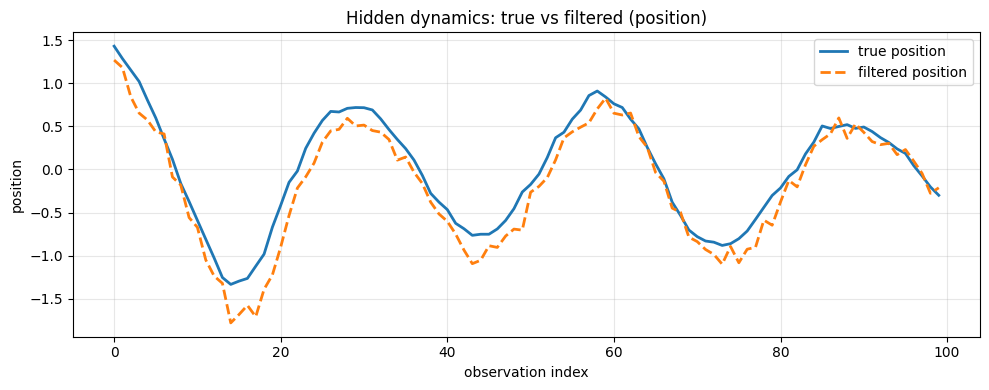

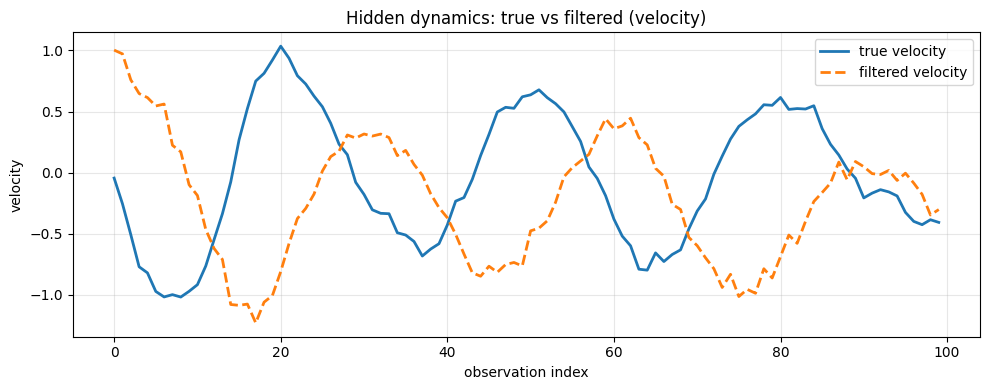

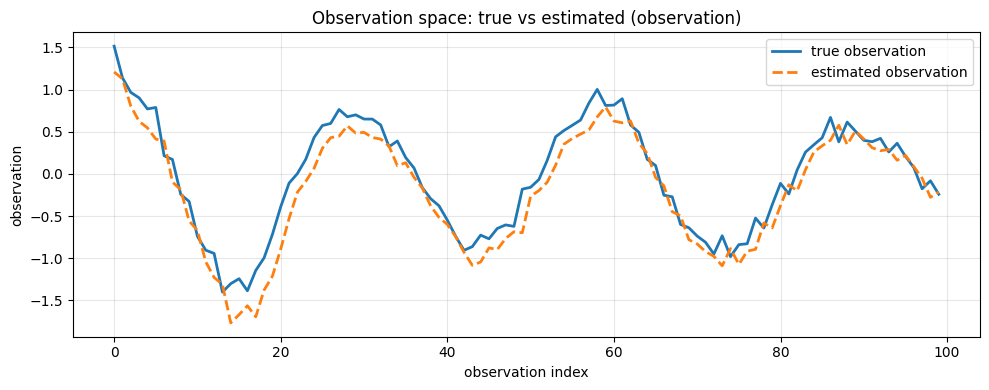

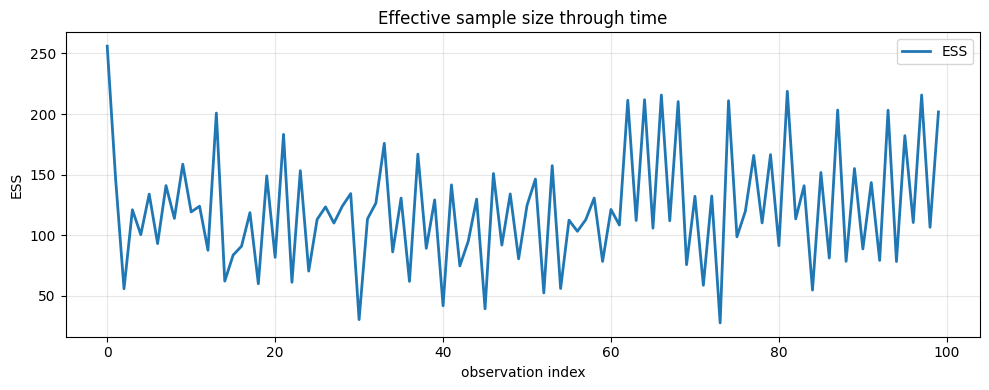

In [34]:
# -----------------------------
# Evaluation
# -----------------------------
dpf.eval()
with torch.no_grad():
    batch_states = test_states[:4].to(device)   # diagnostic only
    batch_obs = test_obs[:4].to(device)

    out = dpf(batch_obs, resample=True)

    state_estimates = out.posterior_state_estimates
    obs_estimates = out.posterior_obs_estimates
    ess = out.ess

    print("batch_states shape:   ", tuple(batch_states.shape))
    print("batch_obs shape:      ", tuple(batch_obs.shape))
    print("state_estimates shape:", tuple(state_estimates.shape))
    print("obs_estimates shape:  ", tuple(obs_estimates.shape))
    print("ess shape:            ", tuple(ess.shape))
    print("state MSE (diagnostic):", F.mse_loss(state_estimates, batch_states).item())
    print("obs MSE:               ", F.mse_loss(obs_estimates, batch_obs).item())
    
    
    plot_filter_results(batch_states, state_estimates, batch_obs, obs_estimates, ess)